## PROYECTO 3

### Imports

In [ ]:
import torch
import os
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from PIL import Image
from collections import defaultdict
import wandb
from Unet import UNet
from VAE import VAE
from latent_analysis import *

## Dataset

### Análisis de distribución

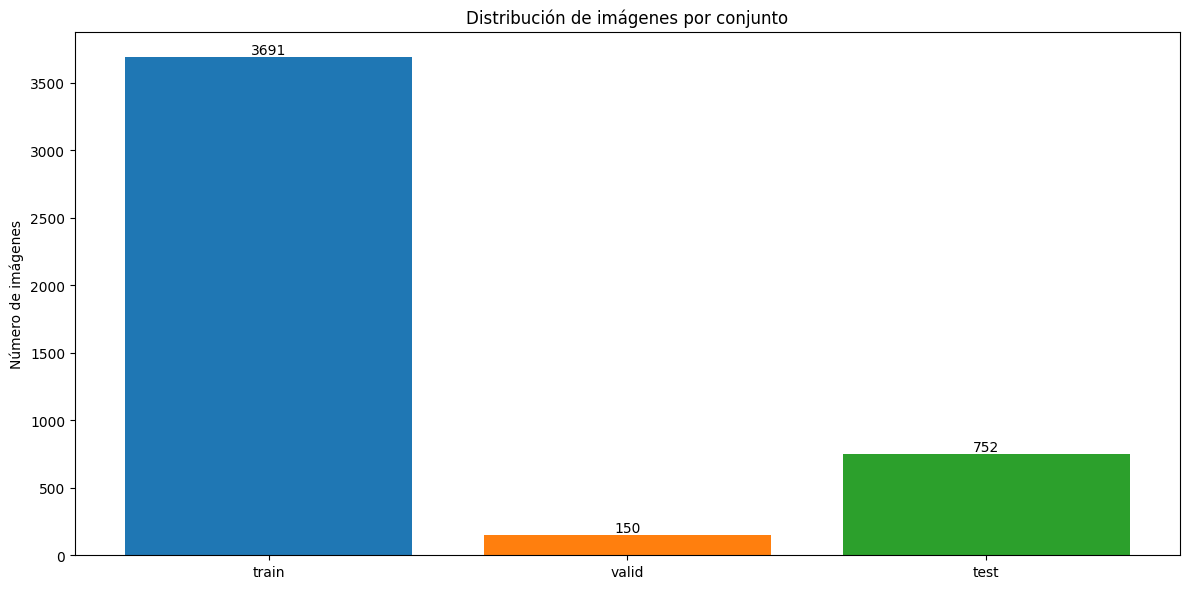

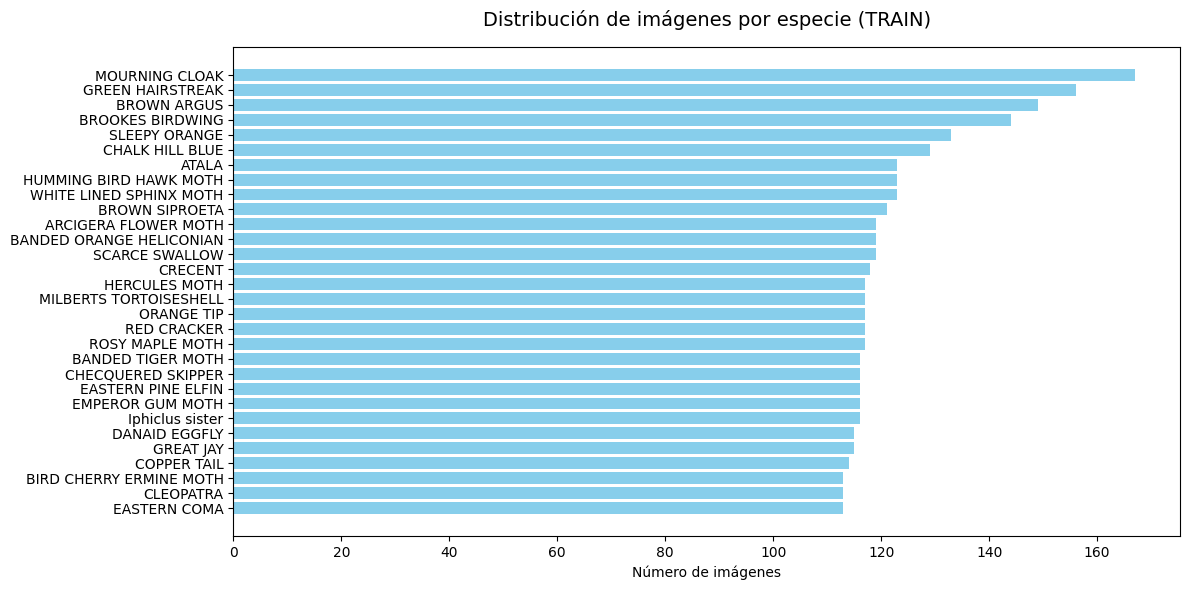

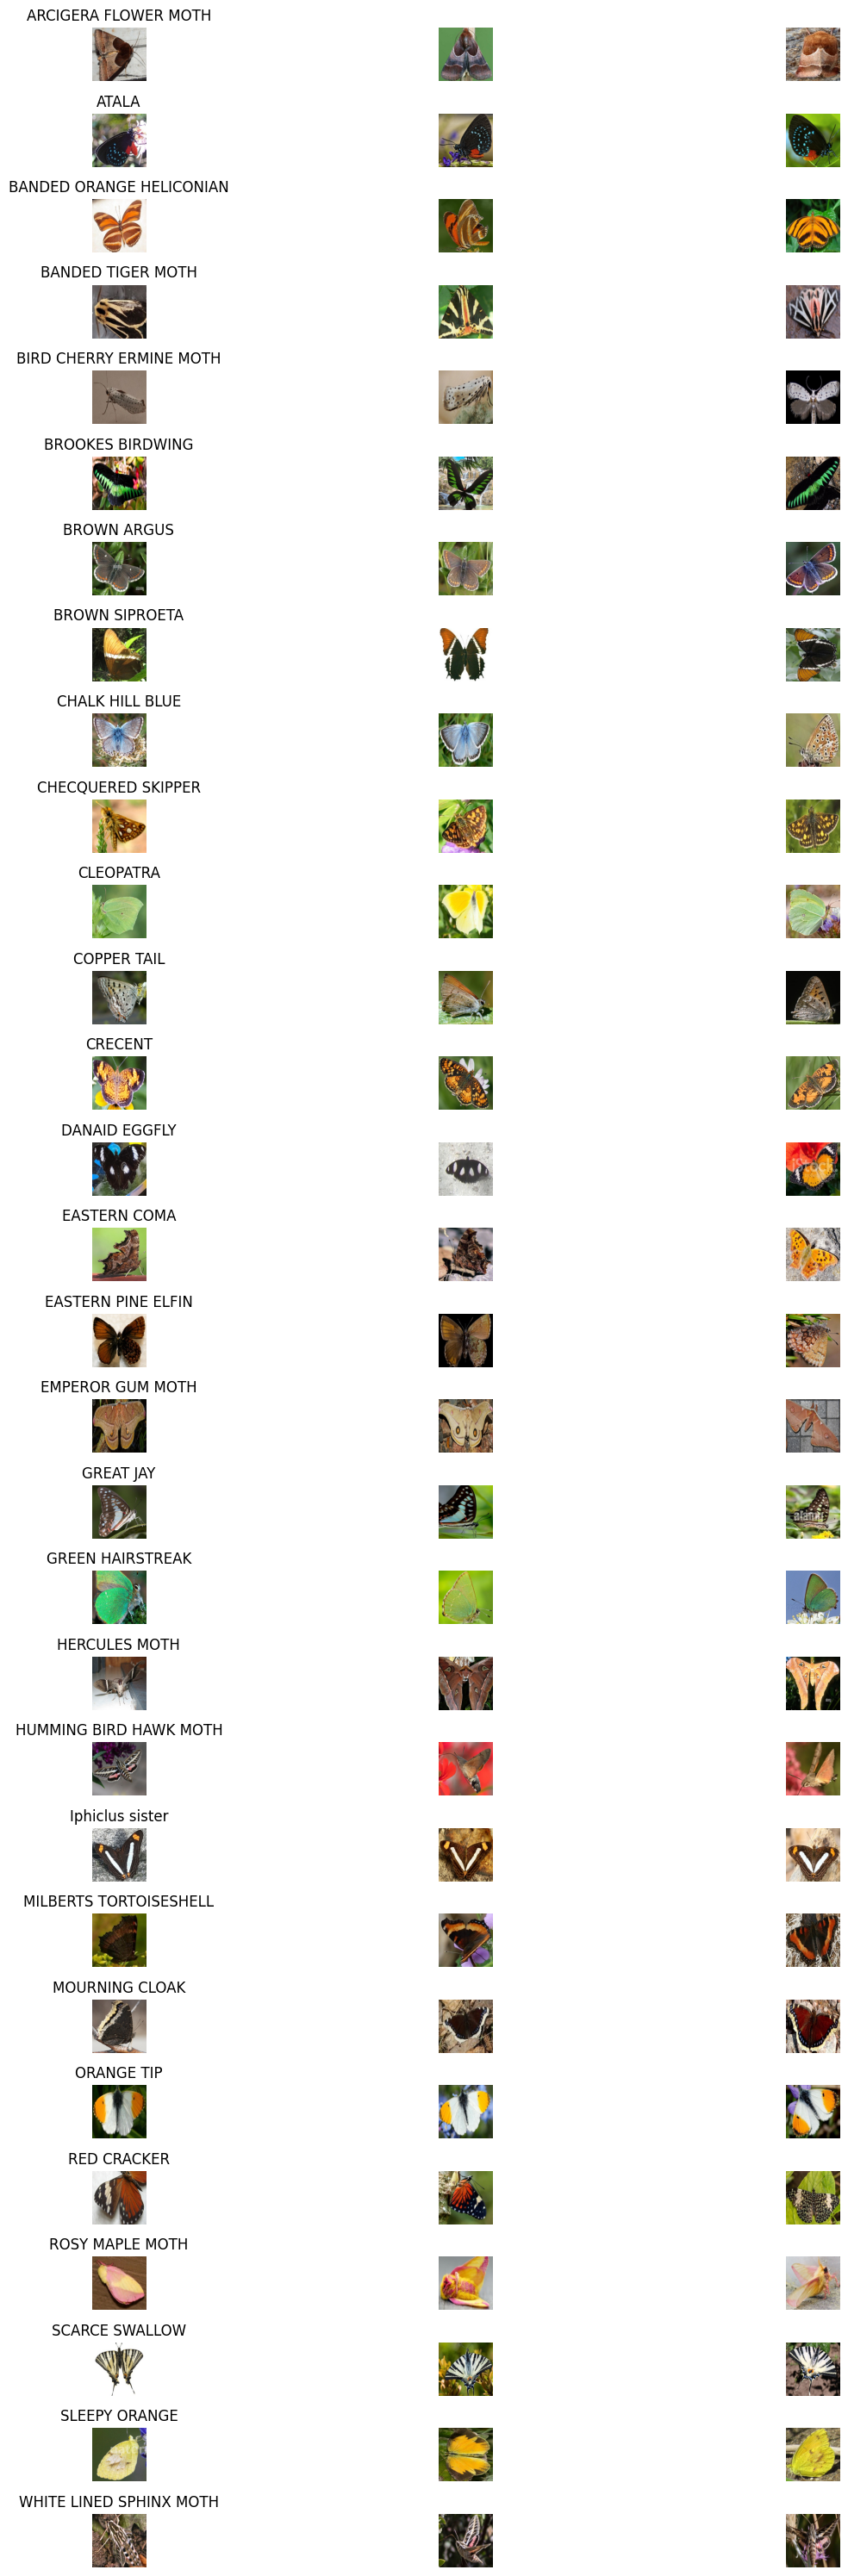

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


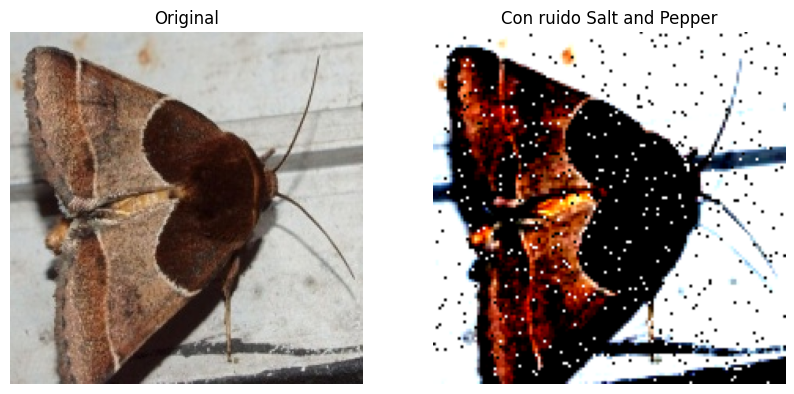

In [9]:
# Análisis de estructura
def analyze_dataset_structure(base_path="dataset"):
    splits = ['train', 'valid', 'test']
    structure = {split: defaultdict(int) for split in splits}
    
    for split in splits:
        split_path = os.path.join(base_path, split)
        for species in os.listdir(split_path):
            species_path = os.path.join(split_path, species)
            if os.path.isdir(species_path):
                num_images = len([f for f in os.listdir(species_path) if f.lower().endswith('.jpg')])
                structure[split][species] = num_images
    return structure

dataset_structure = analyze_dataset_structure()

# Importaciones de los módulos
from utils.data_module import ButterflyDataModule
from utils.transforms import get_denoising_transform
from utils.visualization import plot_distribution, plot_samples_per_species, display_sample_images

# Inicialización y verificación
datamodule = ButterflyDataModule(data_root="dataset", batch_size=32)
datamodule.setup()

# Visualizaciones
plot_distribution(dataset_structure)
plot_samples_per_species(dataset_structure, split='train')
display_sample_images(datamodule.train_dataset, n_samples=3)

# Ejemplo de transformación de denoising
sample_img = Image.open(datamodule.train_dataset.samples[0][0])
noisy_img = get_denoising_transform()(sample_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_img.permute(1, 2, 0))
plt.title("Con ruido Salt and Pepper")
plt.axis('off')
plt.show()

### Usage of Unet

In [10]:
model = UNet(in_channels=3, out_channels=3)  # Reconstrucción RGB
output = model(torch.randn(1, 3, 128, 128))  # input tensor de prueba
print(output.shape)  # Debe dar (1, 3, 128, 128)

torch.Size([1, 3, 128, 128])


### Trainer

In [11]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import WandbLogger

# Logger (si estás usando Weights & Biases)
wandb_logger = WandbLogger(project="butterfly_unet")

# Callback de EarlyStopping (opcional pero recomendado)
early_stop = EarlyStopping(
    monitor="train_loss",  # o "val_loss" si tienes validación
    patience=5,
    verbose=True,
    mode="min"
)

# Ahora sí defines el trainer
trainer = Trainer(
    max_epochs=30,
    callbacks=[early_stop],
    logger=wandb_logger,
    accelerator="auto",  # Usa GPU si hay
    devices=1  # Si estás en GPU, puedes ajustar esto
)


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Hipotesis 1

Función auxiliar para hacer el split por clase:

In [12]:
from sklearn.model_selection import train_test_split
from collections import defaultdict

def split_labeled_unlabeled(dataset, label_percentage=0.3):
    """
    Retorna índices para conjuntos etiquetados y no etiquetados por clase.
    """
    labeled_indices = []
    unlabeled_indices = []

    labels_per_class = defaultdict(list)
    for idx, (_, label) in enumerate(dataset):
        labels_per_class[label].append(idx)

    for label, indices in labels_per_class.items():
        train_idx, test_idx = train_test_split(indices, test_size=(1 - label_percentage), random_state=42)
        labeled_indices.extend(train_idx)
        unlabeled_indices.extend(test_idx)

    return labeled_indices, unlabeled_indices


### Crear Subset de PyTorch

In [13]:
from torch.utils.data import Subset

# Usamos tu DataModule
dm = ButterflyDataModule(data_root="dataset", batch_size=32)
dm.setup()

# Seleccionar subconjunto con etiquetas (30%) y sin etiquetas (70%)
labeled_idx, unlabeled_idx = split_labeled_unlabeled(dm.train_dataset, label_percentage=0.3)

# Subconjuntos
labeled_dataset = Subset(dm.train_dataset, labeled_idx)
unlabeled_dataset = Subset(dm.train_dataset, unlabeled_idx)

### Entrenar Autoencoder (U-Net) con unlabeled_dataset

In [14]:
from torch.utils.data import DataLoader

unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

# Entrenar el autoencoder (usando la clase U-Net definida antes)
trainer.fit(autoencoder, train_dataloaders=unlabeled_loader)

NameError: name 'autoencoder' is not defined

### Extraer el encoder pre-entrando

In [ ]:
pretrained_encoder = UNetEncoder(autoencoder)

### Entrenar clasificadores

In [ ]:
labeled_loader = DataLoader(
    labeled_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

# A: Clasificador desde cero (encoder sin preentrenar)
classifierA = ClassifierA(num_classes=len(dm.classes))
trainer.fit(classifierA, train_dataloaders=labeled_loader)

# B1: Encoder preentrenado congelado
classifierB1 = ClassifierB(pretrained_encoder, num_classes=len(dm.classes), freeze_encoder=True)
trainer.fit(classifierB1, train_dataloaders=labeled_loader)

# B2: Encoder preentrenado fine-tuned
classifierB2 = ClassifierB(pretrained_encoder, num_classes=len(dm.classes), freeze_encoder=False)
trainer.fit(classifierB2, train_dataloaders=labeled_loader)


### Recapitulacion Visual

In [ ]:
# Dataset general con tus clases
dm.setup()
train_dataset = dm.train_dataset

# 70/30 split
labeled_idx, unlabeled_idx = split_labeled_unlabeled(train_dataset, 0.3)

# Subsets
labeled_dataset = Subset(train_dataset, labeled_idx)
unlabeled_dataset = Subset(train_dataset, unlabeled_idx)

# Entrenar autoencoder con unlabeled
trainer.fit(autoencoder, DataLoader(unlabeled_dataset, ...))

# Extraer encoder
pretrained_encoder = UNetEncoder(autoencoder)

# Entrenar clasificadores con labeled
trainer.fit(ClassifierA(), DataLoader(labeled_dataset, ...))
trainer.fit(ClassifierB(pretrained_encoder, freeze=True), ...)
trainer.fit(ClassifierB(pretrained_encoder, freeze=False), ...)


## Hipótesis 2

### Preparación de datos

In [15]:
from utils.data_module import ButterflyDataModule
from torch.utils.data import Subset, DataLoader

dm = ButterflyDataModule(data_root='dataset', batch_size=32)
dm.setup()

### Creación de subsets 70-30

In [16]:
labeled_idx, unlabeled_idx = split_labeled_unlabeled(dm.train_dataset, label_percentage=0.3)
unlabeled_dataset = Subset(dm.train_dataset, unlabeled_idx)  # 70% sin labels

### DataLoader para el VAE (usando solo el 70% sin labels)

In [18]:
unlabeled_loader = DataLoader(
    unlabeled_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4
)

### Entrenamiento del VAE

In [ ]:
vae = VAE(
    in_channels=3,
    out_channels=3,
    noise_p=0.05
)

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_weights', dirpath='./')
    ]
)

trainer.fit(vae, train_dataloaders=unlabeled_loader)  # Solo 70% sin labels

### Extracción de vectores latentes

In [ ]:
from latent_analysis import extract_latent_vectors
latent_vectors, _ = extract_latent_vectors(vae, unlabeled_loader, device='cuda')

### t-SNE y K-Means

In [22]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors.numpy())

# K-Means
kmeans = KMeans(n_clusters=30, random_state=42)
clusters = kmeans.fit_predict(latent_vectors.numpy())

# Visualización
plt.figure(figsize=(10, 8))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=clusters, cmap='tab20', alpha=0.6)
plt.colorbar()
plt.title("Espacio Latente (70% sin labels)")
plt.show()

NameError: name 'latent_vectors' is not defined